# Stored restriction maps visualisations

## 1. Imports

In [281]:
import torch

import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import networkx as nx

#Cornell improved
# 1 Layer Sheaf
# maps = torch.load("/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/maps/DiagSheaf_cornell_fold0_seed43_20260317_111032.pt")

# 2-layer Sheaf
# maps = torch.load("/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/maps/DiagSheaf_cornell_fold0_seed43_20260317_180409.pt")

# 5-layer Sheaf
maps = torch.load("../results/maps/DiagSheaf_cornell_fold0_seed43_20260317_181232.pt")

print(type(maps))

<class 'torch.Tensor'>


## 2. Inspection

In [282]:
print(type(maps))
print(len(maps) if hasattr(maps, '__len__') else "Not iterable")

# If it's a tensor
if isinstance(maps, torch.Tensor):
    print(maps.shape)

# If it's a list or dict
if isinstance(maps, (list, tuple)):
    print(type(maps[0]), maps[0].shape)

if isinstance(maps, dict):
    print(maps.keys())

print(maps[:10])

<class 'torch.Tensor'>
554
torch.Size([554, 3])
tensor([[ 0.0000e+00,  4.2000e+01,  2.0055e-01],
        [ 1.0000e+00,  8.2000e+01, -1.3811e-01],
        [ 1.0000e+00,  9.0000e+01, -1.6641e-01],
        [ 1.0000e+00,  9.9000e+01, -8.1858e-02],
        [ 1.0000e+00,  1.4800e+02, -2.8184e-01],
        [ 2.0000e+00,  4.2000e+01, -5.9332e-01],
        [ 3.0000e+00,  4.2000e+01,  6.7686e-01],
        [ 3.0000e+00,  1.6300e+02,  5.6480e-01],
        [ 4.0000e+00,  8.0000e+00, -4.0644e-01],
        [ 4.0000e+00,  2.5000e+01, -6.0454e-01]])


## 3. Boundary Map

In [283]:
print(maps)

tensor([[ 0.0000e+00,  4.2000e+01,  2.0055e-01],
        [ 1.0000e+00,  8.2000e+01, -1.3811e-01],
        [ 1.0000e+00,  9.0000e+01, -1.6641e-01],
        ...,
        [ 1.7800e+02,  1.4800e+02,  1.1535e-01],
        [ 1.6700e+02,  1.4900e+02,  5.3727e-01],
        [ 1.6000e+02,  1.5700e+02,  7.3564e-01]])


In [284]:
df = pd.DataFrame(maps.cpu().tolist(),columns=["source", "target", "map_value"])

df[["source", "target"]] = df[["source", "target"]].astype(int)
df.sort_values(by=["source", "target"], ascending=[True, True], inplace=True)
df

,source,target,map_value
0,0,42,0.200546
1,1,82,-0.138108
2,1,90,-0.166406
3,1,99,-0.081858
4,1,148,-0.281836
...,...,...,...
486,180,71,-0.277841
534,180,124,0.006715
545,180,142,0.342550
452,181,42,0.437112


In [285]:
df_low = df[df["source"] <= df["target"]]
display(df_low)

df_high = df[df["source"] >= df["target"]]
display(df_high)

,source,target,map_value
0,0,42,0.200546
1,1,82,-0.138108
2,1,90,-0.166406
3,1,99,-0.081858
4,1,148,-0.281836
...,...,...,...
272,148,154,0.302531
273,148,167,0.247434
274,148,178,0.141691
275,149,167,0.433154


,source,target,map_value
285,8,4,0.736807
294,11,6,-0.746835
286,25,4,0.655372
344,30,25,-0.044152
321,31,18,0.604720
...,...,...,...
486,180,71,-0.277841
534,180,124,0.006715
545,180,142,0.342550
452,181,42,0.437112


In [286]:
df = df.copy()
df[["source", "target"]] = df[["source", "target"]].astype(int)

# signed value
df["signed_map"] = np.where(
    df["target"] < df["source"],
    df["map_value"],
    -df["map_value"]
)

# canonical undirected edge label
df["edge"] = df.apply(
    lambda r: (min(r["source"], r["target"]), max(r["source"], r["target"])),
    axis=1
)

# build node-by-edge matrix
nodes = sorted(set(df["source"]).union(df["target"]))
edges = sorted(df["edge"].unique())

B = df.pivot(index="source", columns="edge", values="signed_map")
B = B.reindex(index=nodes, columns=edges, fill_value=0)

B.fillna(0, inplace=True)

In [287]:
B

edge,"(0.0, 42.0)","(1.0, 82.0)","(1.0, 90.0)","(1.0, 99.0)","(1.0, 148.0)","(2.0, 42.0)","(3.0, 42.0)","(3.0, 163.0)","(4.0, 8.0)","(4.0, 25.0)",...,"(141.0, 169.0)","(142.0, 180.0)","(143.0, 145.0)","(144.0, 172.0)","(147.0, 178.0)","(148.0, 154.0)","(148.0, 167.0)","(148.0, 178.0)","(149.0, 167.0)","(157.0, 160.0)"
source,,,,,,,,,,,,,,,,,,,,,
0,-0.200546,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
1,0.000000,0.138108,0.166406,0.081858,0.281836,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
2,0.000000,0.000000,0.000000,0.000000,0.000000,0.593318,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
3,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,-0.676855,-0.564801,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
4,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.406436,0.604537,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
178,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.596055,0.0,0.0,0.115352,0.0,0.0
179,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.00000,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0
180,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.0,0.34255,0.0,0.0,0.000000,0.0,0.0,0.000000,0.0,0.0


In [288]:
((B != 0).sum(axis=0)).value_counts()

2    277
Name: count, dtype: int64

In [289]:
B_np = B.to_numpy(dtype=float)
B_np.shape

(183, 277)

## 4. Laplacian

In [290]:
L0 = B_np @ B_np.T
L0

array([[0.04021854, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.13289713, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.35202588, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.19458111, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.19106714,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.18878977]])

In [291]:
L1 = B_np.T @ B_np
np.all(L1 == L1.T)

np.True_

In [292]:
#Curvature
# F, w/ F[i,j] = L1

In [293]:
# Forman Bochner Decomposition
def fbc(L):
    l=L.shape[0]
    B=L.copy()
    for i in range(l):
        B[i,i]=np.sum(np.abs(L[i,:]))-np.abs(L[i,i])
#B=B.astype(int)
    F=L-B
    return B , F

B1, F1 = fbc(L1)
B1

array([[7.42064047, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.26652526, 0.02298199, ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.02298199, 0.08350281, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.59119841, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.42614715,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.01292838]])

In [294]:
F1

array([[-7.30973355,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -0.19622704,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.12004295, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ..., -0.55781591,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.05013823,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.53072196]])

In [295]:
edge_list = list(B.columns)
print(edge_list)

[(np.float64(0.0), np.float64(42.0)), (np.float64(1.0), np.float64(82.0)), (np.float64(1.0), np.float64(90.0)), (np.float64(1.0), np.float64(99.0)), (np.float64(1.0), np.float64(148.0)), (np.float64(2.0), np.float64(42.0)), (np.float64(3.0), np.float64(42.0)), (np.float64(3.0), np.float64(163.0)), (np.float64(4.0), np.float64(8.0)), (np.float64(4.0), np.float64(25.0)), (np.float64(4.0), np.float64(40.0)), (np.float64(4.0), np.float64(55.0)), (np.float64(4.0), np.float64(72.0)), (np.float64(4.0), np.float64(152.0)), (np.float64(4.0), np.float64(156.0)), (np.float64(5.0), np.float64(37.0)), (np.float64(5.0), np.float64(42.0)), (np.float64(6.0), np.float64(11.0)), (np.float64(6.0), np.float64(42.0)), (np.float64(6.0), np.float64(132.0)), (np.float64(6.0), np.float64(143.0)), (np.float64(6.0), np.float64(145.0)), (np.float64(7.0), np.float64(110.0)), (np.float64(7.0), np.float64(121.0)), (np.float64(8.0), np.float64(42.0)), (np.float64(8.0), np.float64(65.0)), (np.float64(9.0), np.float64(

In [296]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

array([-7.30973355e+00, -1.96227039e-01,  1.20042951e-01, -2.55650931e-01,
       -2.68410010e-01, -7.11953109e+00, -8.70910936e+00, -4.94881457e-02,
       -8.98308012e-01, -2.42136971e+00, -6.10325128e-01, -3.84983227e-01,
       -1.18035925e+00, -7.20707783e-01, -2.12961485e-01, -6.09232208e-01,
       -1.81586985e+01, -2.82086572e-02, -1.13660889e+01,  1.53279905e-01,
       -1.60437841e-02, -1.74205137e-01, -6.32654980e-02, -1.98574857e-01,
       -1.04448900e+01,  3.78083182e-02, -1.48654152e+01, -2.02829705e-01,
       -2.55826275e+00, -2.39739922e+00, -2.47046233e+00, -2.45765277e+00,
       -2.41615760e+00, -2.88189598e+00, -2.53727592e+00, -8.05729661e-01,
       -1.61766663e+01,  6.74427739e-02, -1.29697688e+01, -1.87319812e-01,
        1.42470881e-02, -8.77594606e+00,  2.25657543e-02,  2.47146671e-01,
       -1.72503296e+00, -4.31337280e+00, -7.09563470e-01, -3.88719654e-01,
       -7.45696834e+00, -1.43159293e+00, -8.65804490e-01, -1.44743621e+00,
       -2.33146237e+00, -

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_61565/3886179207.py:10: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


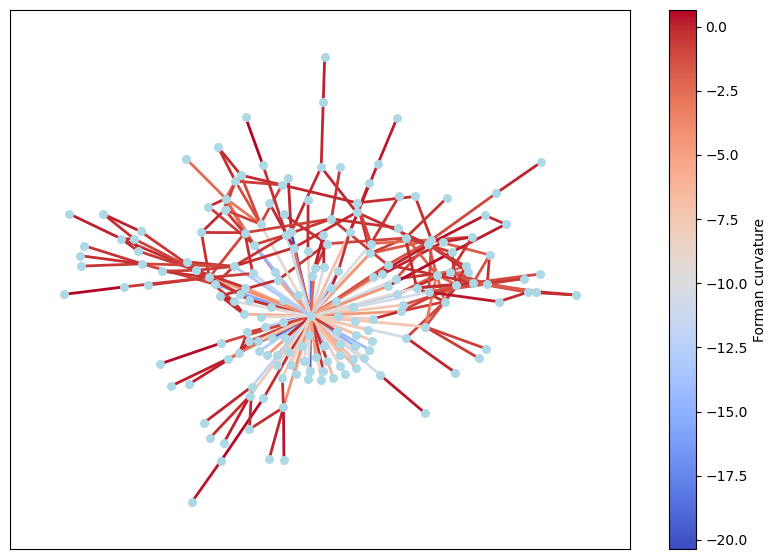

In [297]:
pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax, label='Forman curvature')
f.show()

In [298]:
B0, F0 = fbc(L0)

In [299]:
display(L0)

array([[0.04021854, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.13289713, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.35202588, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.19458111, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.19106714,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.18878977]])

In [300]:
display(F0)
display(B0)

array([[-0.01310109,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        , -0.01432012,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.19161681, ...,  0.        ,
         0.        ,  0.        ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.00828509,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.07428848,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.18693297]])

array([[0.05331964, 0.        , 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.14721725, 0.        , ..., 0.        , 0.        ,
        0.        ],
       [0.        , 0.        , 0.16040907, ..., 0.        , 0.        ,
        0.        ],
       ...,
       [0.        , 0.        , 0.        , ..., 0.18629602, 0.        ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.11677865,
        0.        ],
       [0.        , 0.        , 0.        , ..., 0.        , 0.        ,
        0.0018568 ]])

In [301]:
G= nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)

array([-1.31010945e-02, -1.43201160e-02,  1.91616813e-01,  4.94860364e-01,
       -4.64039375e-01, -2.75388756e-02, -1.09368611e-01,  5.30895877e-02,
        4.76827293e-01,  8.84088843e-03,  2.36219126e+00,  7.50193695e-01,
        1.60838264e-02,  1.15632950e-01,  1.16077584e-02, -6.76953252e-02,
       -4.88774726e-02, -6.29679615e-02,  2.34421900e-01, -9.05452707e-02,
       -8.57414030e-02,  5.09038559e-03, -3.66474320e-02,  2.34172301e-01,
        3.39223865e-01,  6.30691020e-01, -1.25519878e-01, -5.28043460e-02,
       -1.87101327e-03,  8.84730509e-02, -1.21172981e-01,  3.77847818e-01,
        1.11998030e-01,  5.76463803e-01,  1.61759564e-01, -1.21784457e-02,
       -2.44349300e-02, -1.25020136e-01, -1.01919207e-01, -1.02957222e-03,
        4.97249852e-01,  1.07702868e-01,  5.40697483e-03, -4.60982452e-01,
       -8.76660682e-02, -2.29694930e-01, -9.98190079e-02,  2.78006548e-02,
       -1.14124695e-02,  4.87577246e-01,  3.64980322e-01, -7.33242334e-02,
        3.80590565e-01, -

/var/folders/y1/h7g49sfs2z7g4fgb8v4c1bgc0000gn/T/ipykernel_61565/4281192542.py:14: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  f.show()


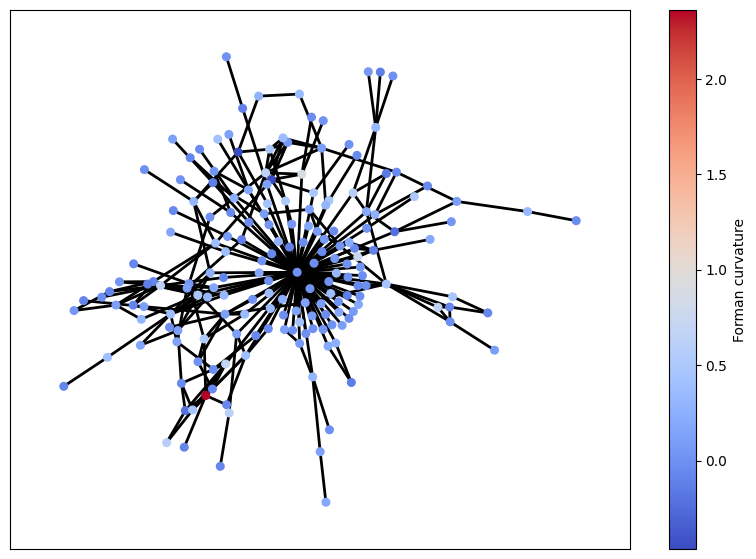

In [302]:

# G.relabel_nodes({i: node for i, node in enumerate(nodes)}, copy=False)
f0 = np.diag(F0)
display(f0)

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,1,figsize=(10,7))
#nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
cmap = plt.cm.coolwarm
norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax, node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax,pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
plt.colorbar(sm0, ax=ax, label='Forman curvature')
f.show()

In [303]:
G.nodes()

NodeView((0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182))

In [304]:
with open("/Users/luigifracassetti/projects/neural-sheaf-diffusion/datasets/cornell/raw/out1_node_feature_label.txt", "r") as f:
    for line in f:
        print(line.strip())
    df_node_feature = pd.read_csv("/Users/luigifracassetti/projects/neural-sheaf-diffusion/datasets/cornell/raw/out1_node_feature_label.txt", sep="\t")

node_id	feature	label
0	0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,

array([3, 0, 2, 3, 4, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 1, 3, 3, 0, 2, 3, 3, 4, 3, 4, 4, 2, 3, 3, 3, 0, 4, 0, 3,
       3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 4, 4, 4, 3, 3, 3, 3,
       0, 3, 3, 3, 4, 3, 3, 4, 4, 3, 0, 3, 0, 3, 4, 3, 2, 4, 2, 4, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 4, 3, 3, 3, 4, 0, 0, 4, 3, 3, 0, 4, 3, 2, 3,
       3, 0, 3, 0, 0, 3, 3, 4, 3, 3, 3, 0, 3, 0, 3, 2, 4, 2, 3, 3, 0, 4,
       3, 4, 3, 4, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3,
       3, 3, 0, 2, 0, 2, 3, 3, 4, 3, 0, 3, 3, 2, 0, 3, 3, 4, 3, 2, 0, 3,
       0, 4, 3, 3, 4, 3, 3])

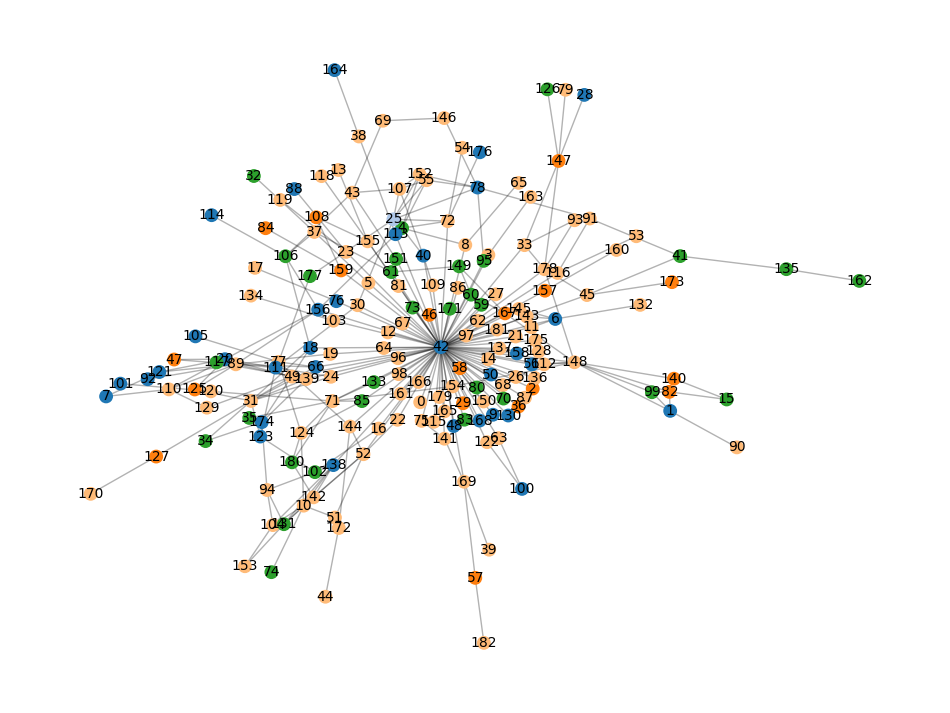

In [305]:
lab = df_node_feature["label"].values
display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx

labels = lab
if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

unique = np.unique(labels)

cmap = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

plt.figure(figsize=(12, 9))
nx.draw_networkx_nodes(G, pos_use, node_color=node_colors, node_size=80)
nx.draw_networkx_edges(G, pos_use, alpha=0.3)
nx.draw_networkx_labels(G, pos=pos_use, font_size=10)
plt.axis('off')
plt.show()

In [306]:
neigh_42_edges =[_ for _  in list(G.edges()) if 42 in _]
display(neigh_42_edges)


[(0, np.float64(42.0)),
 (2, np.float64(42.0)),
 (3, np.float64(42.0)),
 (5, np.float64(42.0)),
 (6, np.float64(42.0)),
 (8, np.float64(42.0)),
 (9, np.float64(42.0)),
 (11, np.float64(42.0)),
 (12, np.float64(42.0)),
 (14, np.float64(42.0)),
 (16, np.float64(42.0)),
 (18, np.float64(42.0)),
 (19, np.float64(42.0)),
 (21, np.float64(42.0)),
 (22, np.float64(42.0)),
 (23, np.float64(42.0)),
 (24, np.float64(42.0)),
 (26, np.float64(42.0)),
 (27, np.float64(42.0)),
 (29, np.float64(42.0)),
 (30, np.float64(42.0)),
 (33, np.float64(42.0)),
 (36, np.float64(42.0)),
 (40, np.float64(42.0)),
 (42, np.float64(45.0)),
 (42, np.float64(46.0)),
 (42, np.float64(48.0)),
 (42, np.float64(49.0)),
 (42, np.float64(50.0)),
 (42, np.float64(52.0)),
 (42, np.float64(56.0)),
 (42, np.float64(58.0)),
 (42, np.float64(59.0)),
 (42, np.float64(60.0)),
 (42, np.float64(61.0)),
 (42, np.float64(62.0)),
 (42, np.float64(63.0)),
 (42, np.float64(64.0)),
 (42, np.float64(66.0)),
 (42, np.float64(67.0)),
 (42, n

In [307]:
neigh_42_nodes = [int(j) if i == 42 else int(i) for (i, j) in neigh_42_edges]
display(neigh_42_nodes)

[0,
 2,
 3,
 5,
 6,
 8,
 9,
 11,
 12,
 14,
 16,
 18,
 19,
 21,
 22,
 23,
 24,
 26,
 27,
 29,
 30,
 33,
 36,
 40,
 45,
 46,
 48,
 49,
 50,
 52,
 56,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 66,
 67,
 68,
 70,
 71,
 72,
 73,
 75,
 76,
 80,
 81,
 83,
 85,
 86,
 87,
 95,
 96,
 97,
 98,
 103,
 109,
 112,
 113,
 115,
 116,
 122,
 128,
 130,
 133,
 136,
 137,
 138,
 139,
 141,
 143,
 144,
 145,
 148,
 150,
 151,
 155,
 156,
 157,
 158,
 159,
 161,
 165,
 166,
 167,
 168,
 169,
 171,
 175,
 178,
 179,
 181]

In [308]:
#associating neighborhing nodes to their labels
neigh_42_labels = {n: int(lab[n]) for n in neigh_42_nodes}
display(neigh_42_labels)

{0: 3,
 2: 2,
 3: 3,
 5: 3,
 6: 0,
 8: 3,
 9: 0,
 11: 3,
 12: 3,
 14: 3,
 16: 3,
 18: 0,
 19: 3,
 21: 3,
 22: 3,
 23: 3,
 24: 3,
 26: 3,
 27: 3,
 29: 2,
 30: 3,
 33: 3,
 36: 2,
 40: 0,
 45: 3,
 46: 2,
 48: 0,
 49: 3,
 50: 0,
 52: 3,
 56: 0,
 58: 2,
 59: 4,
 60: 4,
 61: 4,
 62: 3,
 63: 3,
 64: 3,
 66: 0,
 67: 3,
 68: 3,
 70: 4,
 71: 3,
 72: 3,
 73: 4,
 75: 3,
 76: 0,
 80: 4,
 81: 3,
 83: 4,
 85: 4,
 86: 3,
 87: 3,
 95: 4,
 96: 3,
 97: 3,
 98: 3,
 103: 3,
 109: 3,
 112: 3,
 113: 0,
 115: 3,
 116: 3,
 122: 3,
 128: 3,
 130: 0,
 133: 4,
 136: 3,
 137: 3,
 138: 0,
 139: 3,
 141: 3,
 143: 3,
 144: 3,
 145: 3,
 148: 3,
 150: 3,
 151: 4,
 155: 3,
 156: 0,
 157: 2,
 158: 0,
 159: 2,
 161: 3,
 165: 3,
 166: 3,
 167: 2,
 168: 0,
 169: 3,
 171: 4,
 175: 3,
 178: 3,
 179: 3,
 181: 3}

In [309]:
lab[42]

np.int64(0)

In [310]:
similar_class_ratio = sum(1 for n in neigh_42_nodes if lab[n] == lab[42]) / len(neigh_42_nodes)
similar_class_ratio

0.1595744680851064

### 5.2 Forman Curvature & Classes

array([3, 0, 2, 3, 4, 3, 0, 0, 3, 0, 3, 3, 3, 3, 3, 4, 3, 3, 0, 3, 0, 3,
       3, 3, 3, 1, 3, 3, 0, 2, 3, 3, 4, 3, 4, 4, 2, 3, 3, 3, 0, 4, 0, 3,
       3, 3, 2, 2, 0, 3, 0, 3, 3, 3, 3, 3, 0, 2, 2, 4, 4, 4, 3, 3, 3, 3,
       0, 3, 3, 3, 4, 3, 3, 4, 4, 3, 0, 3, 0, 3, 4, 3, 2, 4, 2, 4, 3, 3,
       0, 3, 3, 3, 0, 3, 3, 4, 3, 3, 3, 4, 0, 0, 4, 3, 3, 0, 4, 3, 2, 3,
       3, 0, 3, 0, 0, 3, 3, 4, 3, 3, 3, 0, 3, 0, 3, 2, 4, 2, 3, 3, 0, 4,
       3, 4, 3, 4, 3, 3, 0, 3, 2, 3, 3, 3, 3, 3, 3, 2, 3, 4, 3, 4, 3, 3,
       3, 3, 0, 2, 0, 2, 3, 3, 4, 3, 0, 3, 3, 2, 0, 3, 3, 4, 3, 2, 0, 3,
       0, 4, 3, 3, 4, 3, 3])

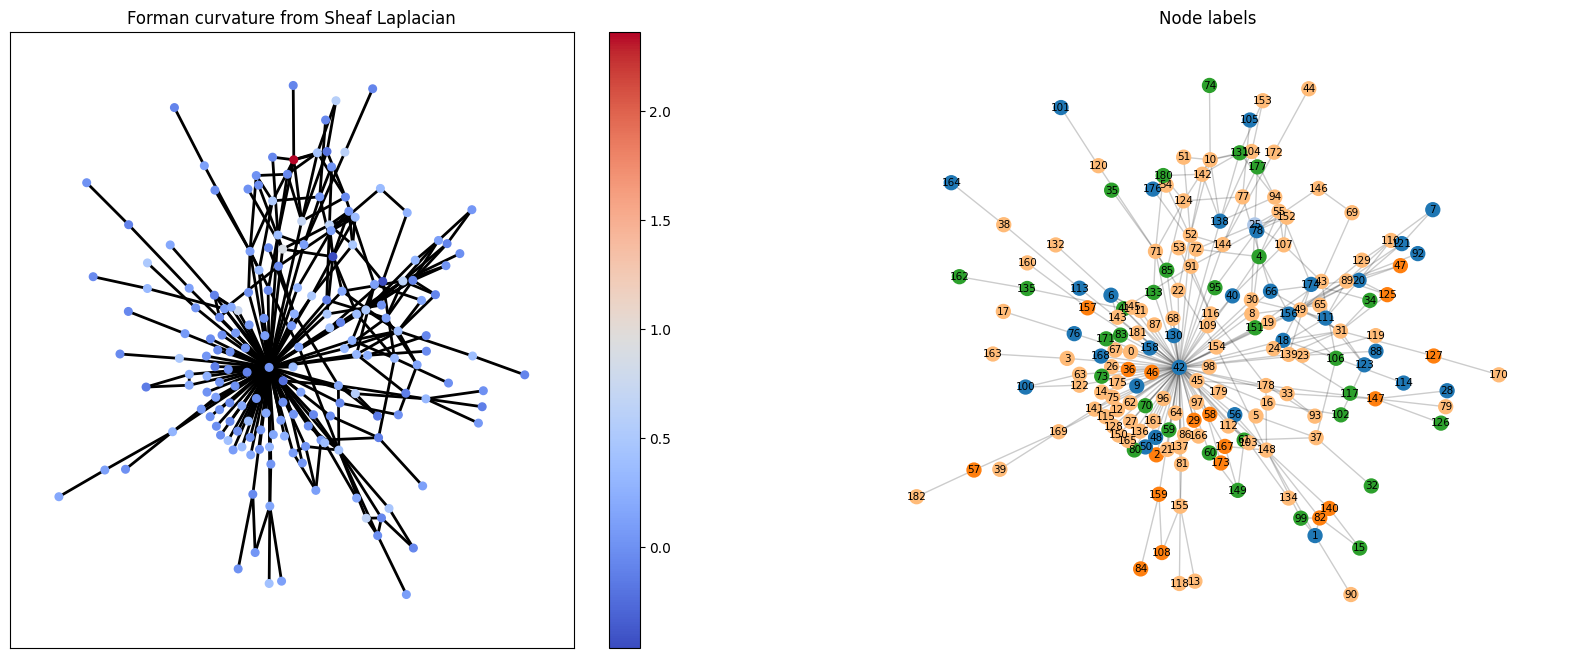

In [311]:
pos = nx.spring_layout(G)
lab = df_node_feature["label"].values
display(lab)

# Plot graph nodes colored by `lab` (handles one-hot or integer labels). Uses existing `G` and `pos` if present.
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

norm0 = plt.Normalize(vmin=f0.min(), vmax=f0.max())
nx.draw_networkx_nodes(G, ax=ax[0], node_color=cmap(norm0(f0)), pos = pos, node_size=30)
nx.draw_networkx_edges(G,ax =ax[0],pos = pos, width=2)
sm0 = plt.cm.ScalarMappable(cmap=cmap, norm=norm0)
ax[0].set_title("Forman curvature from Sheaf Laplacian")
plt.colorbar(sm0, ax=ax[0])

if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

labels = lab
unique = np.unique(labels)

cmap_classes = plt.get_cmap('tab20')
label_to_idx = {val: i for i, val in enumerate(unique)}
node_colors = [cmap_classes(label_to_idx[int(labels[n]) % 20]) for n in sorted(G.nodes())]

pos_use = pos if 'pos' in globals() and isinstance(pos, dict) else nx.spring_layout(G, seed=42)

nx.draw_networkx_nodes(G, ax=ax[1], node_color=node_colors, node_size=100, pos=pos_use)
nx.draw_networkx_edges(G, ax=ax[1], pos=pos_use, alpha=0.2)
nx.draw_networkx_labels(G, ax=ax[1], pos=pos_use, font_size=7.5)
ax[1].set_title("Node labels")
plt.axis('off')

plt.show()

array([-7.30973355e+00, -1.96227039e-01,  1.20042951e-01, -2.55650931e-01,
       -2.68410010e-01, -7.11953109e+00, -8.70910936e+00, -4.94881457e-02,
       -8.98308012e-01, -2.42136971e+00, -6.10325128e-01, -3.84983227e-01,
       -1.18035925e+00, -7.20707783e-01, -2.12961485e-01, -6.09232208e-01,
       -1.81586985e+01, -2.82086572e-02, -1.13660889e+01,  1.53279905e-01,
       -1.60437841e-02, -1.74205137e-01, -6.32654980e-02, -1.98574857e-01,
       -1.04448900e+01,  3.78083182e-02, -1.48654152e+01, -2.02829705e-01,
       -2.55826275e+00, -2.39739922e+00, -2.47046233e+00, -2.45765277e+00,
       -2.41615760e+00, -2.88189598e+00, -2.53727592e+00, -8.05729661e-01,
       -1.61766663e+01,  6.74427739e-02, -1.29697688e+01, -1.87319812e-01,
        1.42470881e-02, -8.77594606e+00,  2.25657543e-02,  2.47146671e-01,
       -1.72503296e+00, -4.31337280e+00, -7.09563470e-01, -3.88719654e-01,
       -7.45696834e+00, -1.43159293e+00, -8.65804490e-01, -1.44743621e+00,
       -2.33146237e+00, -

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 1., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

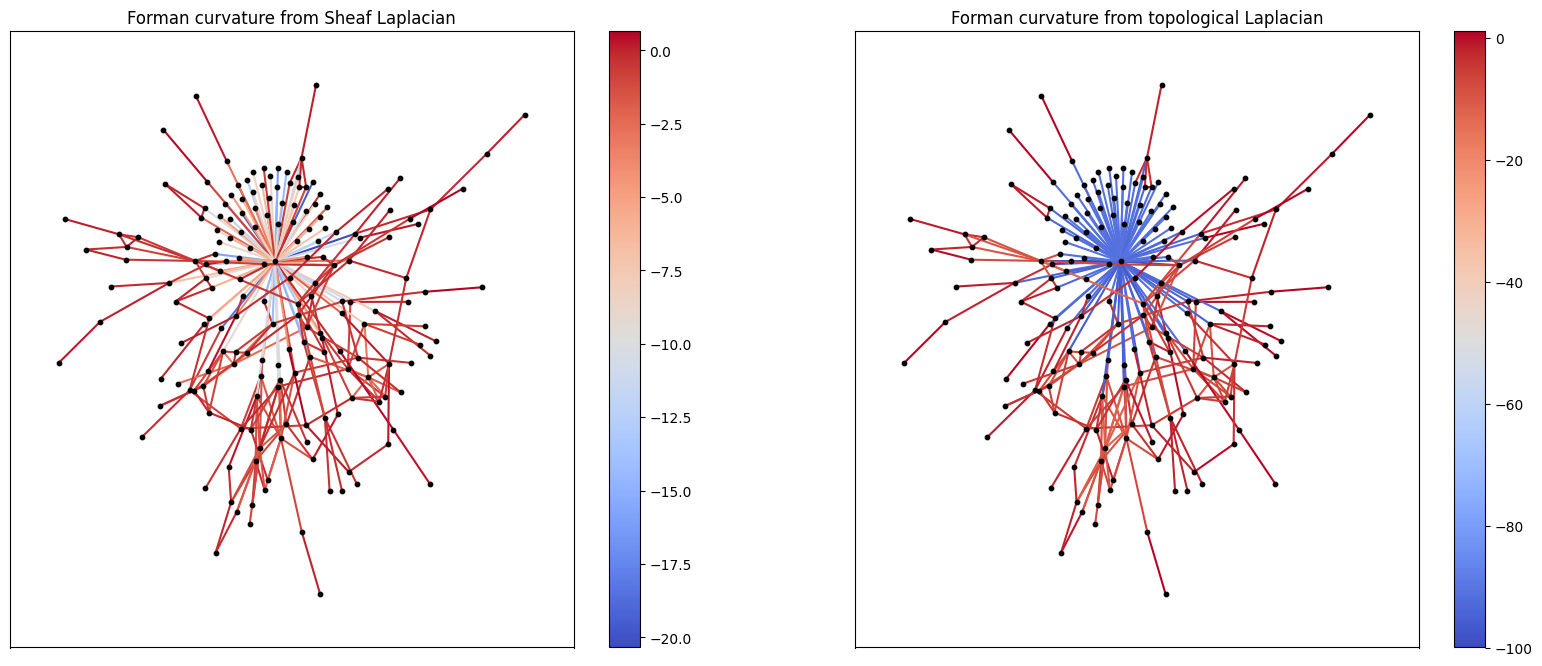

In [312]:
G = nx.Graph()
G.add_nodes_from(B.index)
G.add_edges_from(edge_list)
f1 = np.diag(F1)
display(f1)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1(f1)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
# plt.colorbar(sm1, ax=ax, label='Forman curvature')

B_top = nx.incidence_matrix(G).todense()
L0_top = B_top @ B_top.T
L1_top = B_top.T @ B_top
B0_top, F0_top = fbc(L0_top)
B1_top, F1_top = fbc(L1_top)
f0_top = np.diag(F0_top)
f1_top = np.diag(F1_top)
display(f0_top)
display(B_top)

# pos = nx.spring_layout(G)
# f,ax = plt.subplots(1,1,figsize=(10,7))
# nx.draw_networkx_nodes(G, ax=ax, node_color='lightblue', pos = pos, node_size=30)
# #nx.draw_networkx_labels(G, ax=ax, pos= pos,font_size=8)
# cmap = plt.cm.coolwarm
# norm1_top = plt.Normalize(vmin=f1.min(), vmax=f1.max())
# nx.draw_networkx_edges(G,ax =ax, edge_color = cmap(norm1_top(f1_top)),pos = pos, width=2)
# sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
# plt.colorbar(sm1, ax=ax, label='Forman curvature topological ')
# f.show()

pos = nx.spring_layout(G)
f,ax = plt.subplots(1,2,figsize=(20,8))
cmap = plt.cm.coolwarm

nx.draw_networkx_nodes(G, ax=ax[0], node_color='k', pos = pos, node_size=10)
nx.draw_networkx_nodes(G, ax=ax[1], node_color='k', pos = pos, node_size=10)

norm1 = plt.Normalize(vmin=f1.min(), vmax=f1.max())
norm1_top = plt.Normalize(vmin=f1_top.min(), vmax=f1_top.max())

nx.draw_networkx_edges(G,ax =ax[0], edge_color = cmap(norm1(f1)),pos = pos, width=1.5)
nx.draw_networkx_edges(G,ax =ax[1], edge_color = cmap(norm1_top(f1_top)),pos = pos, width=1.5)

sm1 = plt.cm.ScalarMappable(cmap=cmap, norm=norm1)
plt.colorbar(sm1, ax=ax[0])
sm1_top = plt.cm.ScalarMappable(cmap=cmap, norm=norm1_top)
plt.colorbar(sm1_top, ax=ax[1])

ax[0].set_title("Forman curvature from Sheaf Laplacian")
ax[1].set_title("Forman curvature from topological Laplacian")
plt.show()

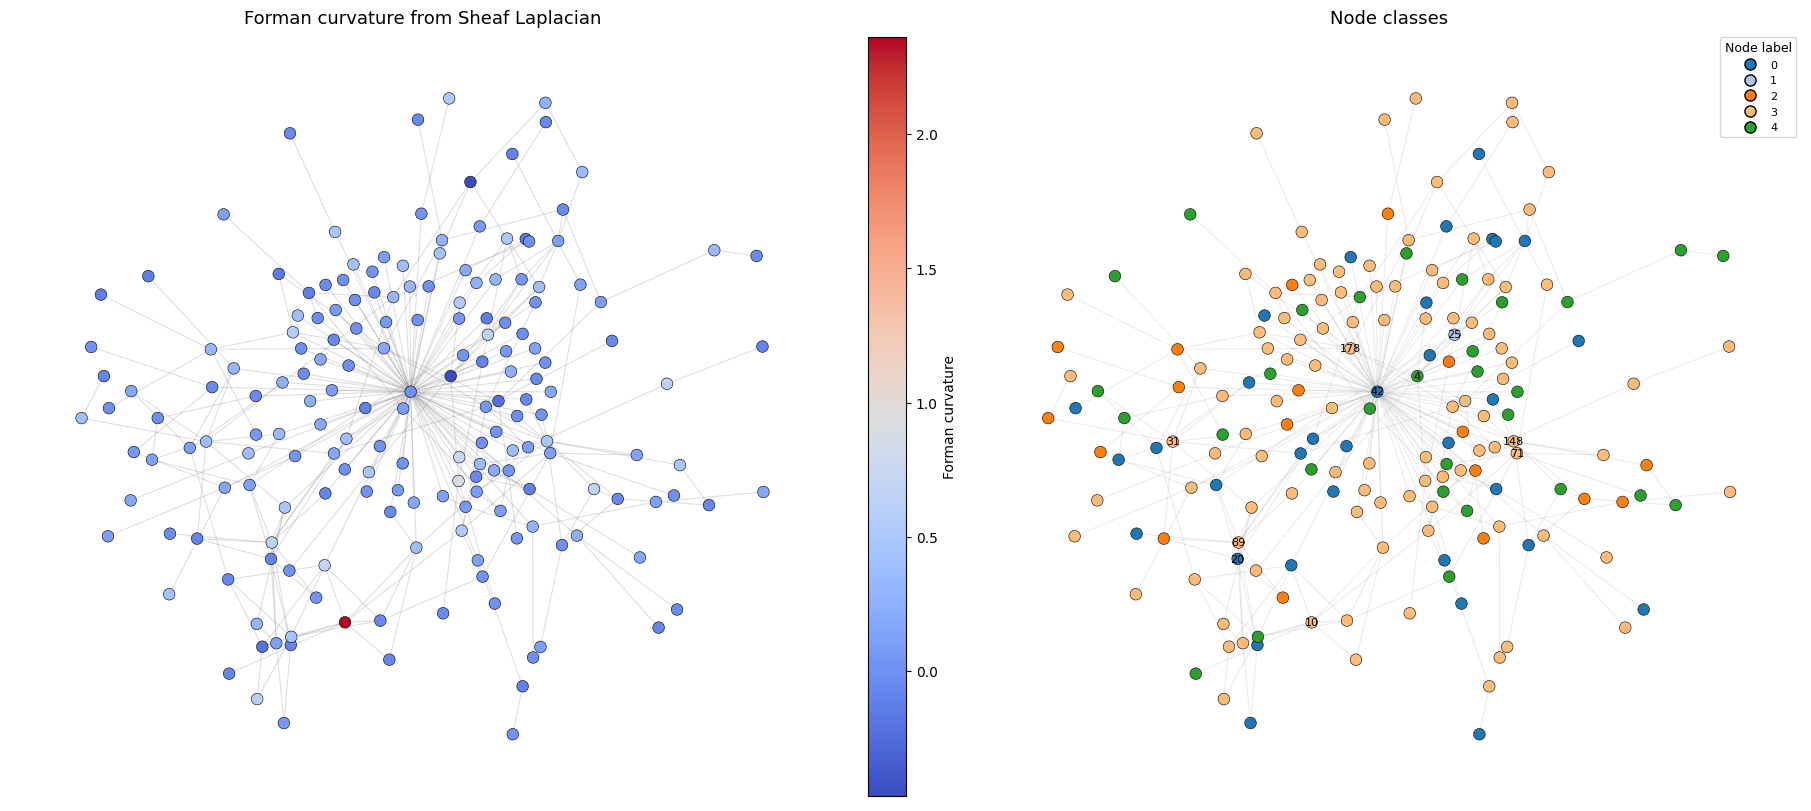

In [313]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from matplotlib.lines import Line2D
from matplotlib.colors import Normalize

# Stable layout
pos = nx.spring_layout(G, seed=42, k=0.25)

labels = df_node_feature["label"].values
if isinstance(labels, np.ndarray) and labels.ndim == 2:
    labels = labels.argmax(axis=1)

# Make sure node ordering matches graph nodes
nodes_sorted = sorted(G.nodes())
labels_sorted = np.array([labels[n] for n in nodes_sorted])
f0_sorted = np.array([f0[n] for n in nodes_sorted])

fig, ax = plt.subplots(1, 2, figsize=(18, 8), constrained_layout=True)

# ------------------------
# Panel 1: curvature plot
# ------------------------
cmap_curv = plt.cm.coolwarm
norm_curv = Normalize(vmin=f0_sorted.min(), vmax=f0_sorted.max())

nx.draw_networkx_edges(
    G,
    pos=pos,
    ax=ax[0],
    width=0.8,
    alpha=0.25,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos=pos,
    ax=ax[0],
    node_color=f0_sorted,
    cmap=cmap_curv,
    vmin=f0_sorted.min(),
    vmax=f0_sorted.max(),
    node_size=70,
    linewidths=0.4,
    edgecolors="black"
)

sm = plt.cm.ScalarMappable(cmap=cmap_curv, norm=norm_curv)
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax[0], fraction=0.046, pad=0.04)
cbar.set_label("Forman curvature")

ax[0].set_title("Forman curvature from Sheaf Laplacian", fontsize=13)
ax[0].set_axis_off()

# ------------------------
# Panel 2: class labels
# ------------------------
unique_labels = np.unique(labels_sorted)
cmap_cls = plt.get_cmap("tab20")
label_to_idx = {val: i for i, val in enumerate(unique_labels)}

node_colors = [cmap_cls(label_to_idx[val] % 20) for val in labels_sorted]

nx.draw_networkx_edges(
    G,
    pos=pos,
    ax=ax[1],
    width=0.8,
    alpha=0.15,
    edge_color="gray"
)

nx.draw_networkx_nodes(
    G,
    pos=pos,
    ax=ax[1],
    node_color=node_colors,
    node_size=70,
    linewidths=0.4,
    edgecolors="black"
)

# Only label a few nodes if desired, not all of them
# example: highest-degree nodes
deg = dict(G.degree())
top_nodes = sorted(deg, key=deg.get, reverse=True)[:10]
label_dict = {n: str(n) for n in top_nodes}

nx.draw_networkx_labels(
    G,
    pos=pos,
    labels=label_dict,
    ax=ax[1],
    font_size=8
)

legend_handles = [
    Line2D([0], [0], marker='o', color='w',
           markerfacecolor=cmap_cls(label_to_idx[val] % 20),
           markeredgecolor='black',
           markersize=8,
           label=str(val))
    for val in unique_labels
]

ax[1].legend(
    handles=legend_handles,
    title="Node label",
    loc="upper right",
    fontsize=8,
    title_fontsize=9,
    frameon=True
)

ax[1].set_title("Node classes", fontsize=13)
ax[1].set_axis_off()

plt.show()

## 5. 2-layer Sheaf

In [314]:
maps = torch.load("/Users/luigifracassetti/projects/neural-sheaf-diffusion/results/maps/DiagSheaf_cornell_fold0_seed43_20260317_180409.pt")

print(type(maps))

<class 'torch.Tensor'>
